# Classificação de `priority` — Support Ticket Priority Dataset (50k)

Construção de um classificador de `priority` (`low` / `medium` / `high`) para os tickets do `ticket_prio_class`. Continuação direta de `1.0-eda-support-ticket-priority-dataset.ipynb`.

**Diferença central em relação a `priority_classification`:** aquele dataset não tinha nenhuma coluna com sinal real (nenhum atributo passava de ~11 p.p. de desvio da taxa base, e nenhum modelo batia um baseline aleatório). Este dataset é o oposto — o `1.0` encontrou sinal forte e real em vários atributos (até 45.6 p.p. de desvio). Também não há aqui o problema de vazamento de "ciclo de vida" do dataset irmão: não existem colunas que só passam a existir após a resolução do chamado (sem timestamps de resposta/fechamento) — tudo está disponível no momento em que o chamado é aberto.

⚠️ **Ressalva herdada do `1.0`:** o split treino/val/test (`ticket_prio_class/modeling/dataset.py`) agrupa por `company_id` para não vazar empresa entre conjuntos — mas só há 25 empresas no dataset inteiro (17 em treino, 4 em val, 4 em test), e a mistura de `priority` varia muito entre empresas. Isso deixou `val.csv`/`test.csv` com distribuições de `priority` bem diferentes entre si (ver seção 1) — a seleção de modelo na seção 5 usa validação cruzada agrupada por empresa dentro do treino como critério principal por causa disso, não só a comparação direta em `val.csv`.


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from ticket_prio_class.modeling.config import PROCESSED_DATA_DIR

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    f1_score,
)
from sklearn.model_selection import StratifiedGroupKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import LinearSVC

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

# Paleta categórica com ordem fixa (identidade da série nunca é ciclada por rank/posição)
CATEGORICAL_PALETTE = [
    "#2a78d6",  # blue
    "#eb6834",  # orange
    "#1baf7a",  # aqua
    "#eda100",  # yellow
    "#e87ba4",  # magenta
    "#008300",  # green
    "#4a3aa7",  # violet
    "#e34948",  # red
]

plt.rcParams.update({
    "axes.prop_cycle": plt.cycler(color=CATEGORICAL_PALETTE),
    "axes.edgecolor": "#c3c2b7",
    "axes.labelcolor": "#0b0b0b",
    "axes.titlecolor": "#0b0b0b",
    "text.color": "#0b0b0b",
    "xtick.color": "#52514e",
    "ytick.color": "#52514e",
    "grid.color": "#e1e0d9",
    "axes.grid": True,
    "grid.linewidth": 0.6,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.facecolor": "#fcfcfb",
    "axes.facecolor": "#fcfcfb",
    "font.size": 11,
})

RANDOM_STATE = 42
PRIORITY_ORDER = ["low", "medium", "high"]

2026-08-27 13:52:03.679 | INFO     | ticket_prio_class.modeling.config:<module>:11 - PROJ_ROOT path is: /home/caiobastos/Documentos/github/estudo_mentoria_caio_octavio/ticket_prio_class


## 1. Carregamento dos dados

In [2]:
train_df = pd.read_csv(PROCESSED_DATA_DIR / "train.csv")
val_df = pd.read_csv(PROCESSED_DATA_DIR / "val.csv")
test_df = pd.read_csv(PROCESSED_DATA_DIR / "test.csv")

print(f"train: {train_df.shape} | val: {val_df.shape} | test: {test_df.shape}")

for name, split_df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    dist = (split_df["priority"].value_counts(normalize=True).reindex(PRIORITY_ORDER) * 100).round(1)
    n_companies = split_df["company_id"].nunique()
    print(f"{name}: {n_companies} empresas | priority % = {dist.to_dict()}")

train: (34741, 33) | val: (6142, 33) | test: (9117, 33)
train: 17 empresas | priority % = {'low': 48.6, 'medium': 37.2, 'high': 14.2}
val: 4 empresas | priority % = {'low': 81.6, 'medium': 17.7, 'high': 0.7}
test: 4 empresas | priority % = {'low': 33.9, 'medium': 38.3, 'high': 27.8}


Confirmado o desbalanceamento *entre splits* já esperado da seção anterior: `val.csv` ficou com quase nenhum ticket `high` e `test.csv` com bem mais `high` do que o treino. Com só 4 empresas em cada um desses splits, um único ticket de uma empresa "atípica" já move a proporção vários pontos percentuais — não dá para tratar a comparação direta em `val.csv` (seção 5) como definitiva.

## 2. Quais atributos usar?

Diferente de `priority_classification`, aqui não existe uma restrição de "momento do ciclo de vida" — o `1.0` confirmou que este dataset não tem nenhuma coluna que só existiria depois da resolução do chamado. A tabela abaixo é sobre qualidade/redundância, não sobre vazamento temporal.

| Coluna(s) | Decisão | Motivo |
|---|---|---|
| `company_size`, `industry`, `customer_tier`, `region`, `product_area`, `booking_channel`, `reported_by_role`, `customer_sentiment`, `day_of_week` | Usar (one-hot) | categóricas nominais com sinal real (achado do `1.0`) |
| `payment_impact_flag`, `security_incident_flag`, `data_loss_flag`, `has_runbook` | Usar (binárias, sem transformação) | indicadores 0/1 prontos; entre os maiores desvios de sinal do `1.0` |
| `org_users`, `past_30d_tickets`, `past_90d_incidents`, `customers_affected`, `error_rate_pct`, `downtime_min`, `description_length` | Usar (padronizado) | contínuas, todas com sinal real (achado do `1.0`) |
| `customer_sentiment` nulo | Preencher com `"unknown"` antes do one-hot | achado do `1.0`: nulo 100% restrito a `booking_channel == "phone"` — uma categoria substantiva, não ruído aleatório |
| Todas as colunas `..._cat` | Excluir | achado do `1.0`: redundantes 1:1 com a versão string — usar as duas juntas duplicaria a mesma informação |
| `priority_cat` | Excluir | é o próprio alvo (`priority`) codificado como inteiro — usá-lo como atributo seria vazamento trivial |
| `ticket_id` | Excluir | identificador, sem sinal preditivo |
| `company_id` | Excluir como atributo (mas usado para agrupar a validação cruzada, seção 5) | identifica só 17 empresas em treino; usá-lo diretamente não generalizaria para empresas novas |

⚠️ **Ressalva herdada do `1.0`:** `company_size`, `industry`, `customer_tier` e `org_users` são constantes por empresa — com só 17 empresas em treino, o sinal que esses atributos carregam tem, na prática, 17 graus de liberdade, não 34.741. Não deixamos de usá-los (são informação legítima e disponível na abertura do chamado), mas essa é exatamente a razão de validar com `StratifiedGroupKFold` agrupado por `company_id` na seção 5, em vez de confiar só numa comparação simples em `val.csv`.

## 3. Preparação de atributos

In [3]:
def prepare_features(data):
    """Preenche o nulo estrutural de `customer_sentiment` (achado do `1.0`: só ocorre em
    tickets por telefone) com uma categoria explícita `"unknown"`."""
    data = data.copy()
    data["customer_sentiment"] = data["customer_sentiment"].fillna("unknown")
    return data


train_feat = prepare_features(train_df)
val_feat = prepare_features(val_df)
test_feat = prepare_features(test_df)

CATEGORICAL_FEATURES = [
    "company_size",
    "industry",
    "customer_tier",
    "region",
    "product_area",
    "booking_channel",
    "reported_by_role",
    "customer_sentiment",
    "day_of_week",
]
FLAG_FEATURES = ["payment_impact_flag", "security_incident_flag", "data_loss_flag", "has_runbook"]
NUMERIC_FEATURES = [
    "org_users",
    "past_30d_tickets",
    "past_90d_incidents",
    "customers_affected",
    "error_rate_pct",
    "downtime_min",
    "description_length",
]
CANDIDATE_FEATURES = CATEGORICAL_FEATURES + FLAG_FEATURES + NUMERIC_FEATURES

X_train, y_train = train_feat[CANDIDATE_FEATURES], train_feat["priority"]
X_val, y_val = val_feat[CANDIDATE_FEATURES], val_feat["priority"]
X_test, y_test = test_feat[CANDIDATE_FEATURES], test_feat["priority"]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL_FEATURES),
        ("flag", "passthrough", FLAG_FEATURES),
        ("num", StandardScaler(), NUMERIC_FEATURES),
    ]
)

## 4. Baseline e candidatos de modelo

Baseline `DummyClassifier(strategy="stratified")` (respeita o balanceamento das classes sem usar nenhum atributo) contra os mesmos três modelos padrão do `scikit-learn` usados em `priority_classification`. `class_weight="balanced"` compensa o desbalanceamento de `priority` (~49% `low` / 37% `medium` / 14% `high` em treino).

In [4]:
candidates = {
    "Baseline (estratificado)": DummyClassifier(strategy="stratified", random_state=RANDOM_STATE),
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Linear SVC": LinearSVC(class_weight="balanced"),
    "Random Forest": RandomForestClassifier(
        n_estimators=300, class_weight="balanced", random_state=RANDOM_STATE
    ),
}

pipelines = {
    name: Pipeline([("preprocessor", preprocessor), ("clf", clf)])
    for name, clf in candidates.items()
}

## 5. Seleção do modelo

Duas comparações, pelo motivo da seção 1:

1. **Validação cruzada agrupada por empresa dentro do treino** (`StratifiedGroupKFold`, 5 folds) — critério principal. Agrupar por `company_id` impede que tickets da mesma empresa apareçam ao mesmo tempo no fold de treino e no de validação de cada rodada (mesma lógica do split principal); estratificar tenta equilibrar `priority` entre folds tanto quanto os grupos permitem. Com 5 folds em vez de 1 split fixo, o resultado é bem menos sensível a qual empresa "atípica" cai em qual conjunto.
2. **Comparação direta em `val.csv`** — mantida por consistência com os outros notebooks do repositório, mas só como checagem secundária, dado o desbalanceamento visto na seção 1.

In [5]:
cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_results = []
for name, pipe in pipelines.items():
    scores = cross_val_score(
        pipe, X_train, y_train, groups=train_feat["company_id"], cv=cv, scoring="f1_macro"
    )
    cv_results.append({
        "modelo": name,
        "cv_macro_f1_media": scores.mean(),
        "cv_macro_f1_desvio": scores.std(),
    })

cv_results_df = pd.DataFrame(cv_results).set_index("modelo").sort_values(
    "cv_macro_f1_media", ascending=False
)
cv_results_df.round(3)

,cv_macro_f1_media,cv_macro_f1_desvio
modelo,,
Random Forest,0.875,0.029
Logistic Regression,0.796,0.042
Linear SVC,0.762,0.052
Baseline (estratificado),0.327,0.008


In [6]:
results = []
val_predictions = {}
for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_val)
    val_predictions[name] = y_pred
    results.append({
        "modelo": name,
        "accuracy": accuracy_score(y_val, y_pred),
        "macro_f1": f1_score(y_val, y_pred, average="macro"),
    })

results_df = pd.DataFrame(results).set_index("modelo").sort_values("macro_f1", ascending=False)
results_df.round(3)

,accuracy,macro_f1
modelo,,
Random Forest,0.955,0.773
Logistic Regression,0.893,0.645
Linear SVC,0.875,0.602
Baseline (estratificado),0.459,0.284


In [7]:
for name, y_pred in val_predictions.items():
    print(f"=== {name} ===")
    print(classification_report(y_val, y_pred, digits=3, zero_division=0))

=== Baseline (estratificado) ===
              precision    recall  f1-score   support

        high      0.007     0.136     0.014        44
         low      0.803     0.482     0.602      5011
      medium      0.174     0.367     0.236      1087

    accuracy                          0.459      6142
   macro avg      0.328     0.328     0.284      6142
weighted avg      0.686     0.459     0.533      6142

=== Logistic Regression ===
              precision    recall  f1-score   support

        high      0.291     0.364     0.323        44
         low      0.926     0.958     0.942      5011
      medium      0.739     0.611     0.669      1087

    accuracy                          0.893      6142
   macro avg      0.652     0.644     0.645      6142
weighted avg      0.888     0.893     0.889      6142

=== Linear SVC ===
              precision    recall  f1-score   support

        high      0.261     0.523     0.348        44
         low      0.890     0.985     0.935      

In [8]:
winner_name = cv_results_df.index[0]
print(
    f"Modelo vencedor (maior macro-F1 médio na validação cruzada agrupada): {winner_name} "
    f"(média = {cv_results_df.loc[winner_name, 'cv_macro_f1_media']:.3f} "
    f"± {cv_results_df.loc[winner_name, 'cv_macro_f1_desvio']:.3f})"
)

val_winner_name = results_df.index[0]
if val_winner_name != winner_name:
    print(
        f"Nota: a comparação direta em val.csv apontaria {val_winner_name} em vez disso "
        f"(macro-F1 = {results_df.loc[val_winner_name, 'macro_f1']:.3f}) — divergência esperada "
        "dado o desbalanceamento de val.csv visto na seção 1; seguimos com o critério da CV."
    )
else:
    print(f"A comparação direta em val.csv concorda: também aponta {val_winner_name}.")

Modelo vencedor (maior macro-F1 médio na validação cruzada agrupada): Random Forest (média = 0.875 ± 0.029)
A comparação direta em val.csv concorda: também aponta Random Forest.


## 6. Avaliação final (`test.csv`)

`test.csv` é tocado **uma única vez**, aqui. O pipeline vencedor já foi treinado em `train.csv` (seção 5, no loop de comparação com `val.csv`) — mantendo a separação ajuste/comparação/avaliação-final.

Accuracy (test): 0.909
Macro-F1 (test): 0.910

              precision    recall  f1-score   support

        high      0.958     0.847     0.899      2532
         low      0.962     0.925     0.943      3094
      medium      0.841     0.941     0.888      3491

    accuracy                          0.909      9117
   macro avg      0.921     0.904     0.910      9117
weighted avg      0.915     0.909     0.910      9117



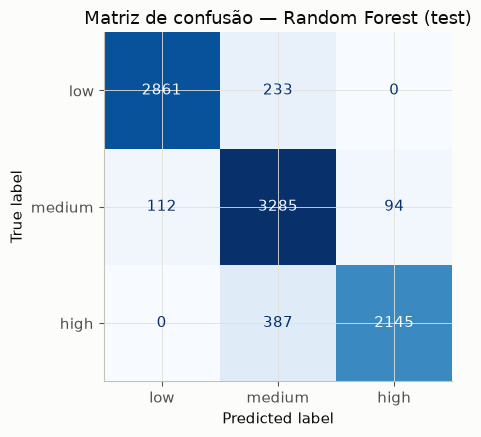

In [9]:
winner_pipeline = pipelines[winner_name]
y_test_pred = winner_pipeline.predict(X_test)

test_accuracy = accuracy_score(y_test, y_test_pred)
test_macro_f1 = f1_score(y_test, y_test_pred, average="macro")
print(f"Accuracy (test): {test_accuracy:.3f}")
print(f"Macro-F1 (test): {test_macro_f1:.3f}")
print()
print(classification_report(y_test, y_test_pred, digits=3, zero_division=0))

fig, ax = plt.subplots(figsize=(5, 4.5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_test_pred, labels=PRIORITY_ORDER, ax=ax, colorbar=False, cmap="Blues"
)
ax.set_title(f"Matriz de confusão — {winner_name} (test)")
plt.tight_layout()
plt.show()

## 7. O que mais pesa na decisão do modelo

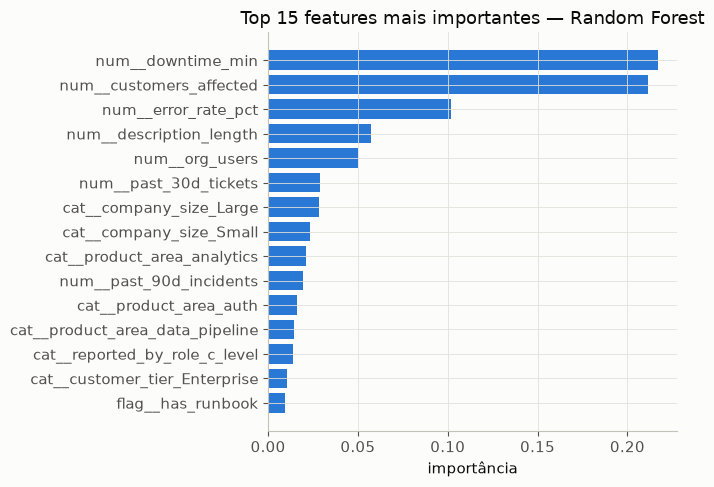

Top 15 respondem por 82.4% da importância total (52 features).


In [10]:
clf = winner_pipeline.named_steps["clf"]
feature_names = winner_pipeline.named_steps["preprocessor"].get_feature_names_out()

if hasattr(clf, "feature_importances_"):
    importances = pd.Series(clf.feature_importances_, index=feature_names).sort_values(ascending=False)
    top = importances.head(15)
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.barh(top.index[::-1], top.values[::-1], color=CATEGORICAL_PALETTE[0])
    ax.set_title(f"Top 15 features mais importantes — {winner_name}")
    ax.set_xlabel("importância")
    plt.tight_layout()
    plt.show()
    print(f"Top 15 respondem por {top.sum() * 100:.1f}% da importância total ({len(feature_names)} features).")
elif hasattr(clf, "coef_"):
    coefs = pd.DataFrame(clf.coef_, index=clf.classes_, columns=feature_names)
    fig, axes = plt.subplots(1, len(clf.classes_), figsize=(4.5 * len(clf.classes_), 5), sharey=True)
    for ax, priority in zip(axes, clf.classes_):
        top = coefs.loc[priority].abs().sort_values(ascending=False).head(10)
        ax.barh(top.index[::-1], coefs.loc[priority, top.index[::-1]], color=CATEGORICAL_PALETTE[0])
        ax.set_title(priority)
    plt.tight_layout()
    plt.show()
else:
    print(f"{winner_name} não expõe coeficientes/importâncias diretamente.")

## 7.5. Auditoria de recall nos tickets raros de alto risco

Achado do `1.0`: `security_incident_flag`, `data_loss_flag` e `payment_impact_flag` têm os maiores desvios de taxa base na EDA (até 45.6 p.p.), mas — achado da seção 7, acima — nenhum aparece no top 15 de importância do `Random Forest`, por serem raros (0.3%-1.6% dos tickets). Macro-F1 agregado não mostra se o modelo realmente acerta esses tickets específicos, que são justamente os de maior risco (incidente de segurança, perda de dados, impacto em pagamento). Essa seção audita isso diretamente, em vez de confiar só no score agregado (`Próximos passos` #1 do resumo original desta análise).

**Nota sobre o método:** não usamos intervalo de confiança (Wilson ou binomial) sobre o recall do subconjunto. Este dataset tem só 17-25 empresas — é exatamente por isso que a seção 5, acima, usa `StratifiedGroupKFold` agrupado por `company_id` em vez de um split simples. O mesmo risco se aplica aqui: um IC assumiria ensaios de Bernoulli independentes, mas o subconjunto raro é dominado por poucas empresas — um IC nessas condições subestimaria a incerteza real, em vez de revelá-la. A quebra por empresa abaixo é o jeito honesto de mostrar essa concentração.

In [11]:
# Baseline fixo para comparação: recall(high) agregado já calculado na seção 6,
# acima (test_macro_f1 usa average="macro"; aqui pegamos o recall por classe).
_aggregate_report = classification_report(
    y_test, y_test_pred, digits=3, zero_division=0, output_dict=True
)
AGGREGATE_HIGH_RECALL = _aggregate_report["high"]["recall"]
print(f"recall(high) agregado em test.csv: {AGGREGATE_HIGH_RECALL:.3f}")


recall(high) agregado em test.csv: 0.847


In [12]:
def report_slice(mask, label, X=test_feat, y_true=y_test, y_pred=y_test_pred):
    """Reporta classification_report + quebra por empresa (recall de `high`) para
    o subconjunto `mask` de `test.csv` — usado para auditar recall em tickets raros
    de alto risco. Não calcula intervalo de confiança (ver nota da seção 7.5): a
    quebra por empresa é o jeito honesto de mostrar a concentração do subconjunto,
    em vez de um IC que assumiria ensaios independentes que este dataset não tem.

    `mask` deve ser um array/Series booleano alinhado por posição com `X`/`y_true`/
    `y_pred` (mesma ordem de `test.csv`, carregado com índice padrão — sem risco de
    desalinhamento aqui, mas documentado por segurança para reuso futuro).
    """
    n = int(mask.sum() if hasattr(mask, "sum") else mask.sum())
    assert n > 0, f"{label}: subconjunto vazio"

    y_true_slice = y_true[mask]
    y_pred_slice = y_pred[mask]

    print(f"=== {label} (N={n}) ===")
    print(classification_report(y_true_slice, y_pred_slice, digits=3, zero_division=0))

    report = classification_report(
        y_true_slice, y_pred_slice, digits=3, zero_division=0, output_dict=True
    )
    recall_high = report.get("high", {}).get("recall", float("nan"))

    per_company = (
        X.loc[mask, ["company_id"]]
        .assign(_true=pd.Series(y_true_slice).to_numpy(), _pred=pd.Series(y_pred_slice).to_numpy())
        .groupby("company_id")
        .apply(
            lambda g: pd.Series({
                "N": len(g),
                "N_high": int((g["_true"] == "high").sum()),
                "recall_high": (
                    (g.loc[g["_true"] == "high", "_pred"] == "high").mean()
                    if (g["_true"] == "high").any()
                    else float("nan")
                ),
            }),
            include_groups=False,
        )
        .sort_values("N_high", ascending=False)
    )

    print(f"recall(high) agregado no subconjunto: {recall_high:.3f} "
          f"(baseline agregado em test.csv: {AGGREGATE_HIGH_RECALL:.3f})")
    print("quebra por empresa (recall de `high`, ordenado por N_high):")
    print(per_company)
    print()

    return recall_high, per_company


In [13]:
RARE_FLAGS = ["security_incident_flag", "data_loss_flag", "payment_impact_flag"]

combined_mask = (X_test[RARE_FLAGS] == 1).any(axis=1)
combined_recall, combined_per_company = report_slice(combined_mask, "combinado (qualquer flag raro)")

per_flag_results = {}
for flag in RARE_FLAGS:
    mask = X_test[flag] == 1
    per_flag_results[flag] = report_slice(mask, flag)


=== combinado (qualquer flag raro) (N=290) ===
              precision    recall  f1-score   support

        high      1.000     0.626     0.770       203
         low      0.500     0.941     0.653        17
      medium      0.412     0.771     0.537        70

    accuracy                          0.679       290
   macro avg      0.637     0.779     0.653       290
weighted avg      0.829     0.679     0.707       290

recall(high) agregado no subconjunto: 0.626 (baseline agregado em test.csv: 0.847)
quebra por empresa (recall de `high`, ordenado por N_high):
                N  N_high  recall_high
company_id                            
100002      176.0   155.0     0.658065
100010       66.0    40.0     0.600000
100020       26.0     7.0     0.142857
100008       22.0     1.0     0.000000

=== security_incident_flag (N=36) ===
              precision    recall  f1-score   support

        high      1.000     0.481     0.650        27
         low      0.143     1.000     0.250    

### Veredito

_(preencher após rodar as células acima — ver seção 7.5 e `ticket_prio_class/docs/designs/rare-class-recall-audit.md` para o critério: "fraco" = recall do subconjunto mais de ~5-10 p.p. abaixo do baseline agregado (impresso acima como `AGGREGATE_HIGH_RECALL`) — mas ler a quebra por empresa antes de decidir; um recall baixo concentrado numa única empresa pequena pesa diferente de um recall baixo espalhado por várias.)_

## 8. Resumo dos principais achados

- **Splits desbalanceados entre si, como esperado (seção 1):** treino 14.2% `high`, val 0.7% `high` (só 44 tickets), test 27.8% `high`. Por isso a validação cruzada agrupada por empresa (5 folds dentro do treino) foi o critério de escolha, não a comparação simples em `val.csv`.
- **`Random Forest` venceu com folga nos dois critérios:** macro-F1 médio de 0.875 ± 0.029 na CV agrupada, contra 0.796 (`Logistic Regression`), 0.762 (`Linear SVC`) e 0.327 (baseline) — a comparação direta em `val.csv` concordou na ordem (`Random Forest` 0.773 de macro-F1 vs. 0.284 do baseline), mas com um valor absoluto bem mais baixo que a CV, justamente pelos só 44 tickets `high` em val (recall de 0.318 nessa classe ali, apesar de precisão 1.0 — amostra pequena demais para uma leitura confiável).
- **Em `test.csv`, o resultado bateu (e superou) a expectativa da CV:** accuracy = 0.909, macro-F1 = **0.910**, com precisão e recall acima de 0.84 nas três classes — bem mais alto que a leitura (enganosamente pessimista) de `val.csv`, e mais próximo do que a CV já apontava. Isso valida a decisão da seção 5 de não confiar só no split fixo de validação.
- **Contraste direto com `priority_classification`:** aquele dataset não tinha nenhum modelo batendo um baseline aleatório (melhor macro-F1 em val ≈ 0.32, igual ao baseline). Aqui o vencedor bate o baseline por uma margem enorme (0.910 vs. ~0.28 de macro-F1 em test) — a suspeita do `1.0` (sinal forte e real) se confirmou na prática.
- **Nem todo atributo com desvio alto no `1.0` virou importância alta no modelo:** `security_incident_flag`, `data_loss_flag` e `payment_impact_flag` tinham os maiores desvios de taxa base na EDA (até 45.6 p.p.), mas nenhum aparece no top 15 de importância do `Random Forest` — são eventos raros (0.3%–1.6% dos tickets), então mesmo com um efeito forte quando ocorrem, contribuem pouco para a redução de impureza média da floresta. Quem domina a importância são as numéricas de impacto mais frequentes: `downtime_min`, `customers_affected` e `error_rate_pct` sozinhas já respondem por mais da metade da importância total.
- **A ressalva da seção 2 sobre atributos firmográficos não inviabilizou o resultado:** `company_size` (`Large`/`Small`) aparece no top 15 de importância, mas com peso bem menor que as numéricas de impacto — e o resultado forte em `test.csv` (empresas nunca vistas em treino) já é evidência de que o modelo generaliza além de memorizar as 17 empresas de treino.

## 9. Próximos passos

1. **Investigar especificamente a recall de `high` nos casos de incidente raro** (`security_incident_flag`/`data_loss_flag`/`payment_impact_flag` = 1) antes de promover o modelo — dado que esses atributos pesam pouco na importância agregada, vale checar à parte se o modelo classifica esses casos raros (mas críticos) corretamente, e não só olhar macro-F1 geral.
2. **Coletar mais empresas antes de um deploy real**, se possível — com só 17-25 empresas no dataset inteiro, o resultado forte em `test.csv` é animador, mas a base de generalização (variedade de empresas) ainda é pequena; mais empresas tornariam a validação cruzada agrupada (seção 5) ainda mais confiável.
3. **Ajustar o split treino/val/test** (`ticket_prio_class/modeling/dataset.py`) se este notebook for evoluir — o desbalanceamento de `val.csv`/`test.csv` encontrado na seção 1 já era conhecido desde a criação do split; vale considerar um `val.csv` maior (mais empresas) ou métricas por-classe explícitas em vez de só macro-F1 agregado.
4. **Promover o pipeline vencedor** (`ColumnTransformer` + `RandomForestClassifier`) para `ticket_prio_class/modeling/train.py`/`predict.py` (ainda não existem — só `dataset.py`/`config.py`), seguindo o padrão Typer `app()` do resto do repositório, já que aqui — ao contrário de `priority_classification` — há um resultado real que justifica ir adiante.